# Credit Default Risk Prediction

## 1. Project Overview

Credit default represents a significant source of financial risk for lending institutions. Identifying customers with a high probability of default can support better credit risk assessment and lending decisions.

The objective of this project is to develop and evaluate machine learning models that predict whether a credit card customer will default on the following month's payment.

The project focuses on:

- Exploring customer demographic, credit, payment, and billing information.
- Identifying variables associated with payment default.
- Building an interpretable baseline model.
- Comparing multiple classification algorithms.
- Evaluating performance using metrics appropriate for imbalanced classification.
- Analyzing the trade-off between detecting risky customers and incorrectly classifying reliable customers.

The target variable is binary:

- `0`: The customer did not default.
- `1`: The customer defaulted.

## 2. Project Setup

This section imports the libraries used throughout the project and defines the main configuration parameters.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Project setup completed successfully.")

Project setup completed successfully.


## 3. Data Source and Description

The dataset used in this project is the **Default of Credit Card Clients** dataset from the UCI Machine Learning Repository.

It contains information about credit card customers in Taiwan, including:

- Credit limits
- Demographic characteristics
- Previous payment status
- Monthly bill amounts
- Monthly payment amounts
- Default status for the following month

The prediction target is binary:

- `0`: The customer did not default.
- `1`: The customer defaulted.

The dataset is downloaded programmatically from UCI to make the analysis reproducible. A local copy is stored in the `data` directory to avoid downloading it every time the notebook is executed.

In [2]:
# Define project directories

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = DATA_DIR / "credit_default_raw.csv"

print(f"Project directory: {PROJECT_DIR}")
print(f"Dataset path: {RAW_DATA_PATH}")

Project directory: /home/juan/Desktop/code of machine lerning cv etc/credit-default-risk-prediction
Dataset path: /home/juan/Desktop/code of machine lerning cv etc/credit-default-risk-prediction/data/credit_default_raw.csv


In [3]:
# Load the dataset from a local file or download it from UCI

if RAW_DATA_PATH.exists(): # checks if the file exists
    df_raw = pd.read_csv(RAW_DATA_PATH)
    print("Dataset loaded from the local file.")

else:
    credit_default_dataset = fetch_ucirepo(id=350)# Identifies the dataset

    features = credit_default_dataset.data.features.copy()# .copy creates a independent copy of the dataframe
    target = credit_default_dataset.data.targets.copy()# contains the variables that we will predict
    identifiers = credit_default_dataset.data.ids # Identifies specific feature of the coustomer

    data_parts = []

    if identifiers is not None:
        data_parts.append(identifiers.copy())

    data_parts.extend([features, target])

    df_raw = pd.concat(data_parts, axis=1)

    # Use a clear and consistent name for the target
    original_target_name = target.columns[0]
    df_raw = df_raw.rename(columns={original_target_name: "default"})

    df_raw.to_csv(RAW_DATA_PATH, index=False)# Saves a local copy

    print("Dataset downloaded from UCI and saved locally.")

Dataset loaded from the local file.


In [4]:
# Inspect the dataset

print(f"Number of observations: {df_raw.shape[0]:,}")
print(f"Number of columns: {df_raw.shape[1]}")

print("\nColumn names:")
print(df_raw.columns.tolist())

display(df_raw.head())

Number of observations: 30,000
Number of columns: 25

Column names:
['ID', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'default']


,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,default
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 4. Data Quality Assessment

Before building predictive models, the dataset is evaluated for structural and data quality issues.

This assessment includes:

- Renaming variables to improve readability
- Verifying the number of observations and variables
- Identifying missing values
- Detecting duplicate records and duplicate identifiers
- Examining data types
- Validating the target variable
- Inspecting categorical codes
- Checking numerical ranges for potentially invalid values

Potential issues are identified in this section but are not automatically removed. Any necessary corrections will be documented and applied during data preprocessing.
We now introduce the names of the features since the names are not given yet

In [5]:
# Create a working copy of the raw dataset

df = df_raw.copy()

column_names = {
    "X1": "limit_balance",
    "X2": "sex",
    "X3": "education",
    "X4": "marriage",
    "X5": "age",
    "X6": "payment_status_sep",
    "X7": "payment_status_aug",
    "X8": "payment_status_jul",
    "X9": "payment_status_jun",
    "X10": "payment_status_may",
    "X11": "payment_status_apr",
    "X12": "bill_amount_sep",
    "X13": "bill_amount_aug",
    "X14": "bill_amount_jul",
    "X15": "bill_amount_jun",
    "X16": "bill_amount_may",
    "X17": "bill_amount_apr",
    "X18": "payment_amount_sep",
    "X19": "payment_amount_aug",
    "X20": "payment_amount_jul",
    "X21": "payment_amount_jun",
    "X22": "payment_amount_may",
    "X23": "payment_amount_apr",
    "Y": "default"
}

df = df.rename(columns=column_names)

print("Column names after renaming:\n")
print(df.columns.tolist())

Column names after renaming:

['ID', 'limit_balance', 'sex', 'education', 'marriage', 'age', 'payment_status_sep', 'payment_status_aug', 'payment_status_jul', 'payment_status_jun', 'payment_status_may', 'payment_status_apr', 'bill_amount_sep', 'bill_amount_aug', 'bill_amount_jul', 'bill_amount_jun', 'bill_amount_may', 'bill_amount_apr', 'payment_amount_sep', 'payment_amount_aug', 'payment_amount_jul', 'payment_amount_jun', 'payment_amount_may', 'payment_amount_apr', 'default']


In [6]:
# General dataset structure

print(f"Observations: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Missing values: {df.isna().sum().sum():,}")
print(f"Complete duplicate rows: {df.duplicated().sum():,}")

Observations: 30,000
Columns: 25
Missing values: 0
Complete duplicate rows: 0


Since duplicated ID represents problems, we test the data quality to avoid such issue

In [7]:
# Check identifier quality
#

if "ID" in df.columns:
    duplicate_ids = df["ID"].duplicated().sum()

    print(f"Unique identifiers: {df['ID'].nunique():,}")
    print(f"Duplicate identifiers: {duplicate_ids:,}")
else:
    print("No separate ID column was provided by UCI.")

Unique identifiers: 30,000
Duplicate identifiers: 0


In [8]:
# Inspect data types

data_types = (
    df.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("data_type")
    .reset_index(name="number_of_columns")
)

display(data_types)

,data_type,number_of_columns
0,int64,25


In [9]:
display(
    df.dtypes
    .astype(str)
    .rename("data_type")
    .to_frame()
)

,data_type
ID,int64
limit_balance,int64
sex,int64
education,int64
marriage,int64
age,int64
payment_status_sep,int64
payment_status_aug,int64
payment_status_jul,int64
payment_status_jun,int64


In [10]:
# Missing-value assessment

missing_values = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

missing_values = missing_values.sort_values(
    by="missing_count",
    ascending=False
)

display(missing_values)

,missing_count,missing_percentage
ID,0,0.00
limit_balance,0,0.00
sex,0,0.00
education,0,0.00
marriage,0,0.00
age,0,0.00
payment_status_sep,0,0.00
payment_status_aug,0,0.00
payment_status_jul,0,0.00
payment_status_jun,0,0.00


We will validate the target variable. This means that we will check if there are unxpected values that may affect our analysis

In [11]:
expected_target_values = {0, 1}
observed_target_values = set(df["default"].dropna().unique())

unexpected_target_values = (
    observed_target_values - expected_target_values
)

print("Observed target values:", observed_target_values)
print("Unexpected target values:", unexpected_target_values)

Observed target values: {np.int64(0), np.int64(1)}
Unexpected target values: set()


In [12]:
# Inspect categorical codes

categorical_columns = [
    "sex",
    "education",
    "marriage"
]

for column in categorical_columns:
    print(f"\nValue counts for '{column}':")
    print(df[column].value_counts(dropna=False).sort_index())


Value counts for 'sex':
sex
1    11888
2    18112
Name: count, dtype: int64

Value counts for 'education':
education
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Value counts for 'marriage':
marriage
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [13]:
# Inspect selected numerical ranges

range_columns = [
    "limit_balance",
    "age",
    "bill_amount_sep",
    "payment_amount_sep"
]

numerical_ranges = pd.DataFrame({
    "minimum": df[range_columns].min(),
    "maximum": df[range_columns].max(),
    "mean": df[range_columns].mean(),
    "median": df[range_columns].median()
})

display(numerical_ranges)

,minimum,maximum,mean,median
limit_balance,10000,1000000,"167,484.32","140,000.00"
age,21,79,35.49,34.00
bill_amount_sep,-165580,964511,"51,223.33","22,381.50"
payment_amount_sep,0,873552,"5,663.58","2,100.00"


In [14]:
# Summarize the initial data quality assessment

quality_summary = pd.DataFrame({
    "assessment": [
        "Number of observations",
        "Number of columns",
        "Total missing values",
        "Complete duplicate rows",
        "Unexpected target values"
    ],
    "result": [
        df.shape[0],
        df.shape[1],
        df.isna().sum().sum(),
        df.duplicated().sum(),
        len(unexpected_target_values)
    ]
})

display(quality_summary)

,assessment,result
0,Number of observations,30000
1,Number of columns,25
2,Total missing values,0
3,Complete duplicate rows,0
4,Unexpected target values,0


## 5. Data Cleaning and Category Preparation

In [15]:
df_clean= df.copy()

In [16]:
np.shape(df_clean)

(30000, 25)

In [17]:
np.shape(df)

(30000, 25)

In [18]:
"ID" in df_clean.columns

True

In [19]:
df_clean=df_clean.drop(columns=["ID"])

In [20]:
"ID" in df_clean.columns

False

The ID does not provide additional information. Thus, we remove it from the features data set

In [21]:
df_clean.columns

Index(['limit_balance', 'sex', 'education', 'marriage', 'age',
       'payment_status_sep', 'payment_status_aug', 'payment_status_jul',
       'payment_status_jun', 'payment_status_may', 'payment_status_apr',
       'bill_amount_sep', 'bill_amount_aug', 'bill_amount_jul',
       'bill_amount_jun', 'bill_amount_may', 'bill_amount_apr',
       'payment_amount_sep', 'payment_amount_aug', 'payment_amount_jul',
       'payment_amount_jun', 'payment_amount_may', 'payment_amount_apr',
       'default'],
      dtype='object')

In [22]:
# Inspect education codes
df_clean["education"].value_counts().sort_index()

# Identify undocumented codes
unexpected_education_codes = [0, 5, 6]

education_mask = df_clean["education"].isin(
    unexpected_education_codes
)

# Count affected records
education_records_reclassified = education_mask.sum()

print(
    "Education records to reclassify:",
    education_records_reclassified
)

# Group undocumented codes into the 'other' category
education_replacements = {
    0: 4,
    5: 4,
    6: 4
}

df_clean["education"] = (
    df_clean["education"]
    .replace(education_replacements)
)

# Validate the result
observed_education_codes = set(
    df_clean["education"].unique()
)

expected_education_codes = {1, 2, 3, 4}

print("Education codes after cleaning:", observed_education_codes)

assert observed_education_codes.issubset(
    expected_education_codes
), "Unexpected education codes remain in the dataset."

Education records to reclassify: 345
Education codes after cleaning: {np.int64(1), np.int64(2), np.int64(3), np.int64(4)}


We will do the same previous procedure but with the the value 0 in the feature "marriage"

In [23]:
# Inspect marriage codes

df_clean["marriage"].value_counts().sort_index()
marriage_val=unexpected_education_codes[0]
marriage_replacements={0:3}

df_clean["marriage"] = (
    df_clean["marriage"]
    .replace(marriage_replacements)
)

observed_marriage_codes = set(
    df_clean["marriage"].unique()
)

print("Marriage codes after cleaning:", observed_marriage_codes)


Marriage codes after cleaning: {np.int64(1), np.int64(2), np.int64(3)}


In [24]:
observed_marriage_codes = {
    int(code) for code in df_clean["marriage"].unique()
}

In [25]:
expected_marriage_codes={1,2,3}

assert observed_marriage_codes.issubset(
    expected_marriage_codes
), "Unexpected marriage codes remain in the dataset."

In [26]:
print("Observations after cleaning:", df_clean.shape[0])

Observations after cleaning: 30000


we proceed to convert numerical codes of "sex", "education" and "marriage" into labels. For instance, we show education = university instead of showign education =2

In [27]:
sex_labels = {
    1: "male",
    2: "female"
}

education_labels = {
    1: "graduate_school",
    2: "university",
    3: "high_school",
    4: "other"
}

marriage_labels = {
    1: "married",
    2: "single",
    3: "other"
}

In [28]:
categorical_columns = [
    "sex",
    "education",
    "marriage"
]


In [29]:
#df_clean["sex"] = df["sex"].copy()

df_clean["sex"] = df_clean["sex"].replace(sex_labels)
df_clean["education"]=df_clean["education"].replace(education_labels)
df_clean["marriage"]=df_clean["marriage"].replace(marriage_labels)



df_clean["education"].value_counts(dropna=False)

education
university         14030
graduate_school    10585
high_school         4917
other                468
Name: count, dtype: int64

In [30]:
df_clean[categorical_columns].isna().sum()

sex          0
education    0
marriage     0
dtype: int64

In [31]:
assert df_clean[categorical_columns].isna().sum().sum() == 0, (
    "Missing values were introduced during category mapping."
)

In [32]:
print(
    "Missing categorical values:",
    df_clean[categorical_columns].isna().sum().sum()
)

Missing categorical values: 0


## 6. Exploratory Data Analysis

This section explores the distribution of credit default and its relationship with customer demographics, credit limits, payment history, bill amounts, and previous payments.

The analysis begins by examining the target distribution to determine whether the classification problem is imbalanced.

In [33]:

default_counts=df_clean["default"].value_counts()

default_percentages=df_clean["default"].value_counts(normalize=True)

default_rate=df_clean["default"].value_counts(normalize=True).mean()

print("overal default rate:", f"{default_percentages[1]:.2%}")

overal default rate: 22.12%


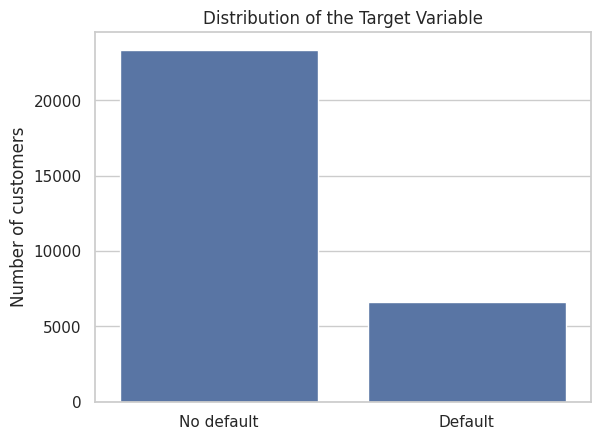

In [34]:
sns.countplot(data=df_clean,x="default")

plt.title("Distribution of the Target Variable")
plt.xlabel("")
plt.xticks([0, 1],["No default", "Default"])
plt.ylabel("Number of customers")
plt.show()


### Target Distribution

The target distribution shows that most customers did not default on the following month's payment. Approximately **22.12%** of customers defaulted, while **77.88%** did not.

This indicates a moderate class imbalance. A model that predicts only the majority class would achieve relatively high accuracy while failing to identify any customers at risk of default.

Consequently, accuracy alone will not be sufficient to evaluate model performance. Precision, recall, F1-score, ROC-AUC, and the precision-recall curve will also be considered.

### Default Rate by Education

The default rate is compared across education categories to examine whether payment behavior differs between customer groups.

In [35]:
default_counts = (
    df_clean["default"]
    .value_counts()
    .sort_index()
)

default_percentages = (
    df_clean["default"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

default_rate = df_clean["default"].mean()

print("Overall default rate:", f"{default_rate:.2%}")

Overall default rate: 22.12%


In [36]:
df_clean_grouped = df_clean.groupby(
    "education",
    observed=True
)

education_default_rate = (
    df_clean_grouped["default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(education_default_rate)

education
high_school       25.16
university        23.73
graduate_school   19.23
other              7.05
Name: default, dtype: float64


In [37]:
education_default_rate_df = (
    education_default_rate
    .rename("default_rate")
    .reset_index()
)

display(education_default_rate_df)

,education,default_rate
0,high_school,25.16
1,university,23.73
2,graduate_school,19.23
3,other,7.05


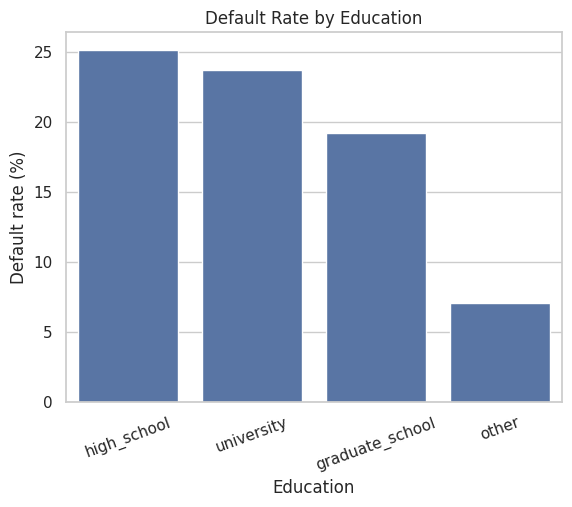

In [38]:
sns.barplot(x=education_default_rate.index,
    y=education_default_rate.values)

plt.title("Default Rate by Education")
plt.xlabel("Education")
plt.ylabel("Default rate (%)")
plt.xticks(rotation=20)
plt.show()


### Default Rate by Education

Customers with a high-school education present the highest observed default rate, followed by customers with a university education. Customers with graduate-school education show a lower default rate.

The `other` category presents the lowest observed rate. However, this category contains fewer observations and includes undocumented education codes that were grouped during data cleaning. Its result should therefore be interpreted carefully.

These results describe associations within this dataset and do not demonstrate that education level causes credit default.

### Default Rate by Marital Status

In section, we will do a similar analysis to the previous section, but we will consider the marriage status as main variable to analyze. This will provide information about how the relation is betweeen a default and marriage status. 

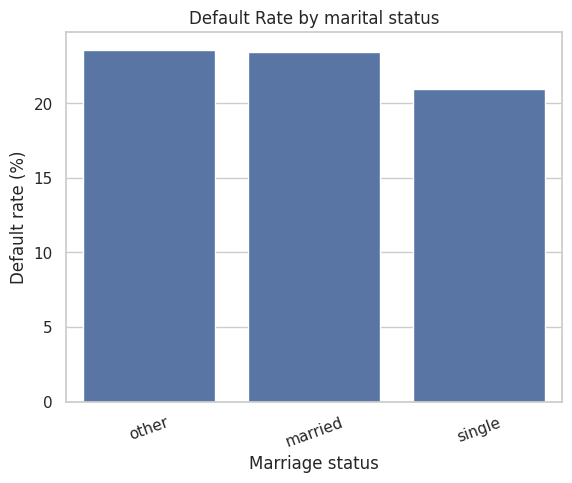

marriage
other     23.61
married   23.47
single    20.93
Name: default, dtype: float64


In [39]:
# we gouped according to the marriage status
df_marriage_grouped=df_clean.groupby("marriage", observed=True)
marriage_default_rate = (
    df_marriage_grouped["default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)


sns.barplot(x=marriage_default_rate.index,
    y=marriage_default_rate.values)

plt.title("Default Rate by marital status")
plt.xlabel("Marriage status")
plt.ylabel("Default rate (%)")
plt.xticks(rotation=20)
plt.show()
print(marriage_default_rate)

### Default Rate by Marital Status

The observed default rate varies across marital-status categories. The other group presents the highest default rate with **23.61%**, while the single status has the lowest one with **20.93%** .

It is important to note that the `other` category contains fewer observations than the main categories, so its default rate may be less stable and should be interpreted carefully.

These results show an association within the dataset but do not imply that marital status causes credit default since the rate values are close. 

### Default Rate by Sex

This analysis compares observed default rates between demographic groups. Because sex is a sensitive attribute, the results are used for exploratory and fairness analysis rather than as evidence of a causal relationship.

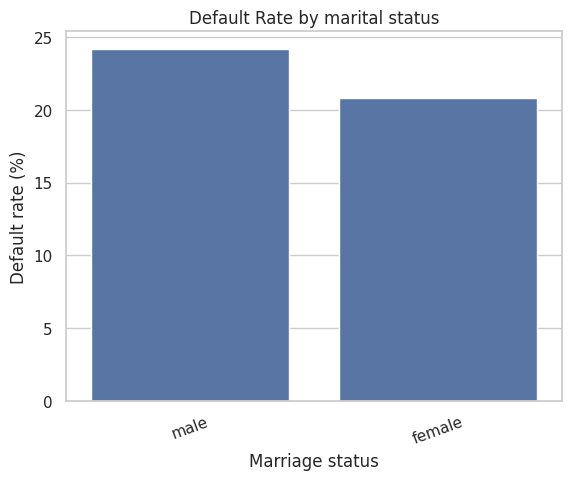

sex
male     24.17
female   20.78
Name: default, dtype: float64


In [40]:
# we gouped according to the marriage status
df_sex_grouped=df_clean.groupby("sex", observed=True)
sex_default_rate = (
    df_sex_grouped["default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)


sns.barplot(x=sex_default_rate.index,
    y=sex_default_rate.values)

plt.title("Default Rate by marital status")
plt.xlabel("Marriage status")
plt.ylabel("Default rate (%)")
plt.xticks(rotation=20)
plt.show()
print(sex_default_rate)

### Credit Limit and Default

This analysis compares the distribution of credit limits between customers who defaulted and those who did not. Because financial variables may contain extreme values, both summary statistics and distribution-based visualizations are considered.

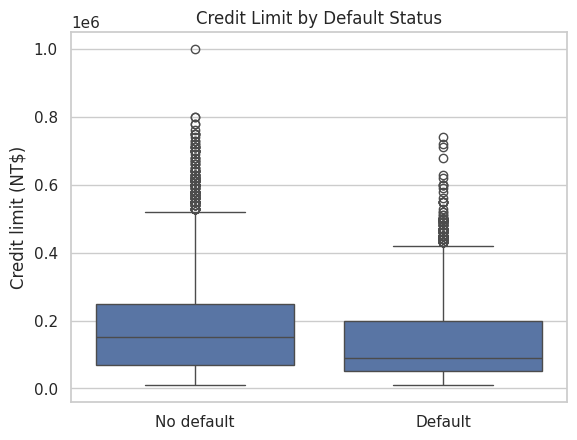

         count       mean     median        std
default                                        
0        23364 178,099.73 150,000.00 131,628.36
1         6636 130,109.66  90,000.00 115,378.54


In [41]:
# we gouped according to the marriage status
df_balance_grouped=df_clean.groupby("default", observed=True)
limit_balance_statistics = (
    df_balance_grouped["limit_balance"]
    .agg(["count", "mean", "median", "std"])
)


sns.boxplot(data=df_clean,x="default",y="limit_balance")

plt.title("Credit Limit by Default Status")
plt.xlabel("")
plt.ylabel("Credit limit (NT$)")
plt.xticks([0, 1], ["No default", "Default"])
plt.show()
print(limit_balance_statistics)

### Interpretation
The previous plot shows the credit limit for the non-default and default scenarios. The blue box has the 50% of the clients for both cases and the inner line is the median of the distributions. The upper circles represent values that are far for the usual values.

We observe that customers who did not default present a higher median credit limit than customers who defaulted. However, the two distributions overlap considerably, indicating that credit limit alone is not sufficient to distinguish between the two classes.

Several customers have credit limits substantially above the typical range. These observations were retained because they represent plausible high credit limits rather than confirmed data errors.

### Recent Payment Status and Default

The most recent payment status records whether a customer was current on payments or had experienced a payment delay. This analysis examines how the observed default rate changes with the severity of the most recent delay.



In [42]:
df_clean["payment_status_sep"].value_counts().sort_index()

payment_status_sep
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

the positive values represent delayed months. The negative and zero values will be grouped in the category "no recorded delay".

In [43]:
bins = [-np.inf,0,1,2,np.inf]

delay_labels = [
    "No recorded delay",
    "1 month delay",
    "2 months delay",
    "3+ months delay"
]

In [44]:
payment_status_category=pd.cut(
    df_clean["payment_status_sep"],
    bins=bins,
    labels=delay_labels ,
    include_lowest=True
)
df_clean["recent_delay_group"]=payment_status_category

In [45]:
df_clean["recent_delay_group"].value_counts(
    dropna=False
)

recent_delay_group
No recorded delay    23182
1 month delay         3688
2 months delay        2667
3+ months delay        463
Name: count, dtype: int64

In [46]:
df_delay_group=df_clean.groupby("recent_delay_group", observed=True)
delay_default_rate = (
    df_delay_group["default"]
    .mean()
    .mul(100)
)

df_delay_frame=delay_default_rate.rename("default_rate").reset_index()

display(df_delay_frame)


,recent_delay_group,default_rate
0,No recorded delay,13.83
1,1 month delay,33.95
2,2 months delay,69.14
3,3+ months delay,71.92


We observe that the default rates increases with the number of delayed months. We may show this in a plot to easily compare the rates

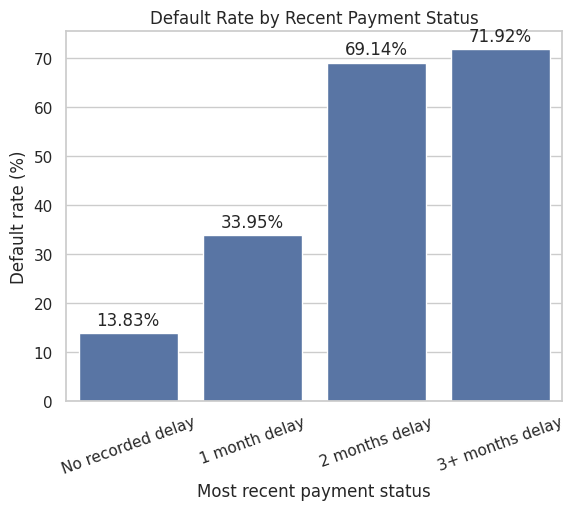

In [47]:
default_rate_plot=sns.barplot(
    data=df_delay_frame,
    x="recent_delay_group",
    y="default_rate"
)

for container in default_rate_plot.containers:
    default_rate_plot.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )



plt.title("Default Rate by Recent Payment Status")
plt.xlabel("Most recent payment status")
plt.ylabel("Default rate (%)")
plt.xticks(rotation=20)
plt.show()

### Interpretation

The observed default rate increases as the severity of the most recent payment delay increases. Customers with no recorded delay present the lowest default rate, while customers with longer delays show substantially higher rates.

This suggests that recent payment behavior contains important predictive information. However, the relationship is associative and does not prove that a payment delay alone causes future default.

## 7. Feature Engineering

New variables are created from the customer's six-month payment history, bill amounts, and previous payments. These features summarize financial behavior in forms that may be more informative than individual monthly observations.

In [48]:
payment_status_columns = [
    "payment_status_sep",
    "payment_status_aug",
    "payment_status_jul",
    "payment_status_jun",
    "payment_status_may",
    "payment_status_apr"
]

In [49]:
df_six_months=df_clean[payment_status_columns] > 0
df_clean["months_with_delay"]=df_six_months.sum(axis=1)


payment_delays_six_months = (
    df_clean["months_with_delay"]
)

print(payment_delays_six_months.head())

0    2
1    2
2    0
3    0
4    0
Name: months_with_delay, dtype: int64


In [50]:
#df_clean["months_with_delay"].groupby("default").mean().mul(100)


df_delay_monthly=df_clean.groupby("months_with_delay", observed=True)
delay_months_default_rate = (
    df_delay_monthly["default"]
    .mean()
    .mul(100)
)

In [51]:
assert df_clean["months_with_delay"].between(0, 6).all()

print(
    df_clean["months_with_delay"]
    .value_counts()
    .sort_index()
)

months_with_delay
0    19931
1     4426
2     1899
3     1154
4      951
5      298
6     1341
Name: count, dtype: int64


In [52]:
delay_months_default_rate_df = (
    delay_months_default_rate
    .rename("default_rate")
    .reset_index()
)

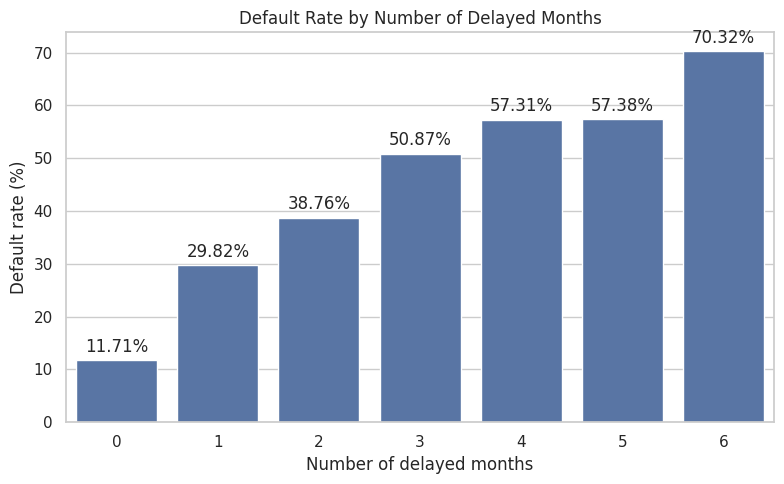

In [53]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=delay_months_default_rate_df,
    x="months_with_delay",
    y="default_rate"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.title("Default Rate by Number of Delayed Months")
plt.xlabel("Number of delayed months")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.show()

### Delayed Months and Default Risk

The default rate generally increases with the number of months in which a customer experienced a payment delay. Customers with no delayed months present the lowest observed default rate, while customers with repeated delays show considerably higher default rates.

This engineered feature summarizes six monthly payment-status variables and captures the persistence of payment difficulties. The relationship is associative and does not imply that repeated delays alone cause default.

### Additional Engineered Features

Additional variables summarize the severity of payment delays and the customer's billing and payment behavior over the six-month observation period.


In [54]:
# Create additional behavioral features

bill_amount_columns = [
    "bill_amount_sep",
    "bill_amount_aug",
    "bill_amount_jul",
    "bill_amount_jun",
    "bill_amount_may",
    "bill_amount_apr"
]

payment_amount_columns = [
    "payment_amount_sep",
    "payment_amount_aug",
    "payment_amount_jul",
    "payment_amount_jun",
    "payment_amount_may",
    "payment_amount_apr"
]

df_clean["maximum_delay"] = (
    df_clean[payment_status_columns]
    .clip(lower=0)
    .max(axis=1)
)

df_clean["average_bill_amount"] = (
    df_clean[bill_amount_columns].mean(axis=1)
)

df_clean["average_payment_amount"] = (
    df_clean[payment_amount_columns].mean(axis=1)
)

df_clean["total_bill_amount"] = (
    df_clean[bill_amount_columns].sum(axis=1)
)

df_clean["total_payment_amount"] = (
    df_clean[payment_amount_columns].sum(axis=1)
)


In [55]:
# Validate the engineered features

engineered_features = [
    "months_with_delay",
    "maximum_delay",
    "average_bill_amount",
    "average_payment_amount",
    "total_bill_amount",
    "total_payment_amount"
]

assert df_clean["months_with_delay"].between(0, 6).all()
assert df_clean["maximum_delay"].ge(0).all()
assert df_clean[engineered_features].isna().sum().sum() == 0

display(df_clean[engineered_features + ["default"]].head())


,months_with_delay,maximum_delay,average_bill_amount,average_payment_amount,total_bill_amount,total_payment_amount,default
0,2,2,"1,284.00",114.83,7704,689,1
1,2,2,"2,846.17",833.33,17077,5000,1
2,0,0,"16,942.17","1,836.33",101653,11018,0
3,0,0,"38,555.67","1,398.00",231334,8388,0
4,0,0,"18,223.17","9,841.50",109339,59049,0


The engineered variables provide compact summaries of repeated payment behavior. `months_with_delay` measures the persistence of delays, while `maximum_delay` measures their greatest observed severity. Aggregate bill and payment variables summarize the customer's recent financial activity.


## 8. Data Preparation and Preprocessing

The cleaned dataset is divided into training, validation, and test sets using stratified sampling. The validation set is used for model comparison and threshold selection, while the test set remains untouched until the final evaluation.

Numerical variables are standardized, and categorical variables are converted using one-hot encoding. These operations are contained in a scikit-learn pipeline to reduce the risk of data leakage.


In [56]:
# Import modeling and evaluation tools

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.calibration import CalibrationDisplay


In [57]:
# Separate predictors and target

columns_not_used_for_modeling = [
    "default",
    "recent_delay_group"
]

X = df_clean.drop(
    columns=columns_not_used_for_modeling,
    errors="ignore"
)
y = df_clean["default"].astype(int)

# Create an untouched test set
X_train_validation, X_test, y_train_validation, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Split the remaining data into training and validation sets
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_validation,
    y_train_validation,
    test_size=0.25,
    stratify=y_train_validation,
    random_state=RANDOM_STATE
)

print(f"Training observations: {X_train.shape[0]:,}")
print(f"Validation observations: {X_validation.shape[0]:,}")
print(f"Test observations: {X_test.shape[0]:,}")

print(f"Training default rate: {y_train.mean():.2%}")
print(f"Validation default rate: {y_validation.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")


Training observations: 18,000
Validation observations: 6,000
Test observations: 6,000
Training default rate: 22.12%
Validation default rate: 22.12%
Test default rate: 22.12%


In [58]:
# Define preprocessing by feature type

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))


Categorical features: ['sex', 'education', 'marriage']
Number of numerical features: 26


## 9. Baseline Model

A `DummyClassifier` that always predicts the most frequent class provides a minimum performance reference. Because the target is imbalanced, accuracy alone can make this baseline appear stronger than it is. Recall, F1-score, ROC-AUC, and average precision are therefore also reported.


In [59]:
# Define a reusable evaluation function

def calculate_classification_metrics(y_true, y_pred, y_probability):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "average_precision": average_precision_score(
            y_true,
            y_probability
        )
    }


In [60]:
# Train and evaluate the baseline on the validation set

baseline_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent",
                random_state=RANDOM_STATE
            )
        )
    ]
)

baseline_model.fit(X_train, y_train)

baseline_validation_predictions = baseline_model.predict(
    X_validation
)
baseline_validation_probabilities = baseline_model.predict_proba(
    X_validation
)[:, 1]

baseline_validation_metrics = calculate_classification_metrics(
    y_validation,
    baseline_validation_predictions,
    baseline_validation_probabilities
)

display(
    pd.DataFrame(
        baseline_validation_metrics,
        index=["Dummy baseline"]
    ).round(3)
)


,accuracy,precision,recall,f1_score,roc_auc,average_precision
Dummy baseline,0.78,0.00,0.00,0.00,0.50,0.22


The baseline can achieve relatively high accuracy by predicting the majority class, but its recall for defaulting customers is zero. This illustrates why accuracy is insufficient for this risk-classification problem.


## 10. Model Training and Validation

Two complementary models are compared:

- **Logistic Regression:** an interpretable linear model commonly used as a strong baseline for binary classification.
- **Random Forest:** a nonlinear ensemble capable of representing interactions between customer characteristics and payment behavior.

Balanced class weights are used to give greater importance to the minority default class. Model selection is performed on the validation set using average precision, which is informative for imbalanced classification.


In [61]:
# Define candidate models

candidate_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=300,
                    min_samples_leaf=2,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    )
}


In [62]:
# Train candidate models and compare validation performance

fitted_models = {}
validation_results = {}

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)

    validation_predictions = model.predict(X_validation)
    validation_probabilities = model.predict_proba(
        X_validation
    )[:, 1]

    validation_results[model_name] = (
        calculate_classification_metrics(
            y_validation,
            validation_predictions,
            validation_probabilities
        )
    )

    fitted_models[model_name] = model

validation_results_df = (
    pd.DataFrame(validation_results)
    .T
    .sort_values(
        by="average_precision",
        ascending=False
    )
)

display(validation_results_df.round(3))

best_model_name = validation_results_df.index[0]
best_model = fitted_models[best_model_name]

print(f"Selected model: {best_model_name}")


,accuracy,precision,recall,f1_score,roc_auc,average_precision
Random Forest,0.82,0.62,0.43,0.51,0.78,0.54
Logistic Regression,0.75,0.45,0.62,0.52,0.76,0.51


Selected model: Random Forest


## 11. Decision Threshold and Cost Analysis

The conventional threshold of 0.50 is not necessarily optimal for credit-risk decisions. A false negative means failing to identify a customer who defaults, while a false positive means flagging a customer who would repay.

For demonstration purposes, a false negative is assigned a cost five times greater than a false positive. These values are illustrative and should be replaced with institution-specific financial costs in a real application. The threshold is selected exclusively on the validation set.


In [63]:
# Estimate validation probabilities with the selected model

validation_probabilities = best_model.predict_proba(
    X_validation
)[:, 1]

false_positive_cost = 1
false_negative_cost = 5

threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.01):
    threshold_predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        threshold_predictions,
        labels=[0, 1]
    ).ravel()

    total_cost = (
        false_positive_cost * fp
        + false_negative_cost * fn
    )

    threshold_results.append({
        "threshold": threshold,
        "false_positives": fp,
        "false_negatives": fn,
        "recall": recall_score(
            y_validation,
            threshold_predictions,
            zero_division=0
        ),
        "precision": precision_score(
            y_validation,
            threshold_predictions,
            zero_division=0
        ),
        "estimated_cost": total_cost
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_results_df.loc[
    threshold_results_df["estimated_cost"].idxmin()
]

selected_threshold = float(
    best_threshold_row["threshold"]
)

display(best_threshold_row.to_frame("value").round(3))
print(f"Selected validation threshold: {selected_threshold:.2f}")


,value
threshold,0.20
false_positives,"1,729.00"
false_negatives,305.00
recall,0.77
precision,0.37
estimated_cost,"3,254.00"


Selected validation threshold: 0.20


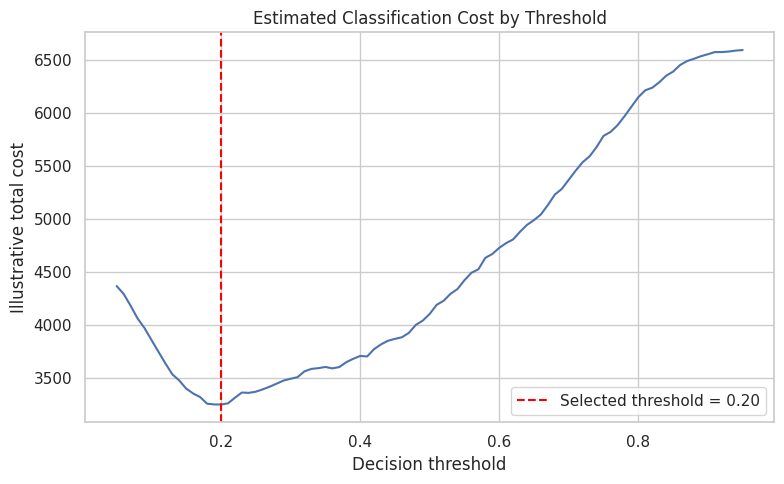

In [64]:
# Visualize the cost associated with each threshold

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=threshold_results_df,
    x="threshold",
    y="estimated_cost"
)

plt.axvline(
    selected_threshold,
    color="red",
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.2f}"
)

plt.title("Estimated Classification Cost by Threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Illustrative total cost")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Final Model Evaluation

The selected model is evaluated once on the untouched test set. Results are reported for both the conventional 0.50 threshold and the threshold selected through validation cost analysis.


In [65]:
# Evaluate the selected model on the untouched test set

test_probabilities = best_model.predict_proba(X_test)[:, 1]

test_predictions_default_threshold = (
    test_probabilities >= 0.50
).astype(int)

test_predictions_selected_threshold = (
    test_probabilities >= selected_threshold
).astype(int)

test_metrics_default = calculate_classification_metrics(
    y_test,
    test_predictions_default_threshold,
    test_probabilities
)

test_metrics_selected = calculate_classification_metrics(
    y_test,
    test_predictions_selected_threshold,
    test_probabilities
)

test_results_df = pd.DataFrame(
    {
        "Threshold 0.50": test_metrics_default,
        f"Threshold {selected_threshold:.2f}": test_metrics_selected
    }
).T

display(test_results_df.round(3))


,accuracy,precision,recall,f1_score,roc_auc,average_precision
Threshold 0.50,0.81,0.60,0.43,0.50,0.77,0.54
Threshold 0.20,0.65,0.36,0.75,0.49,0.77,0.54


In [66]:
# Display class-specific performance

print(
    classification_report(
        y_test,
        test_predictions_selected_threshold,
        target_names=["No default", "Default"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

  No default       0.90      0.63      0.74      4673
     Default       0.36      0.75      0.49      1327

    accuracy                           0.65      6000
   macro avg       0.63      0.69      0.61      6000
weighted avg       0.78      0.65      0.68      6000



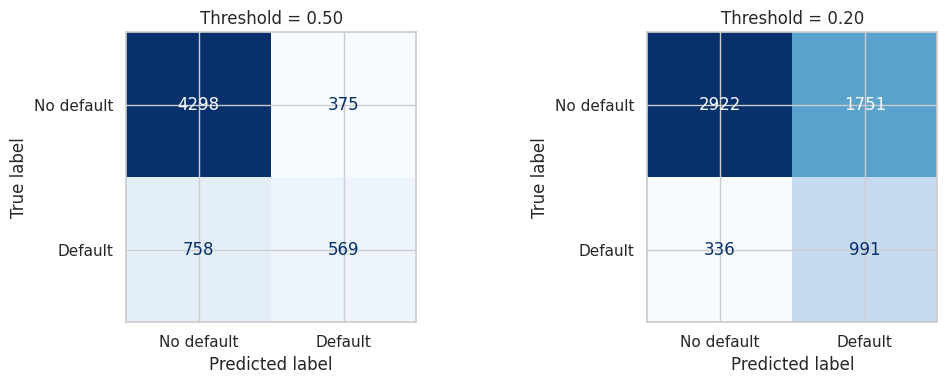

In [67]:
# Compare confusion matrices for both thresholds

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions_default_threshold,
    display_labels=["No default", "Default"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)
axes[0].set_title("Threshold = 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions_selected_threshold,
    display_labels=["No default", "Default"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title(f"Threshold = {selected_threshold:.2f}")

plt.tight_layout()
plt.show()


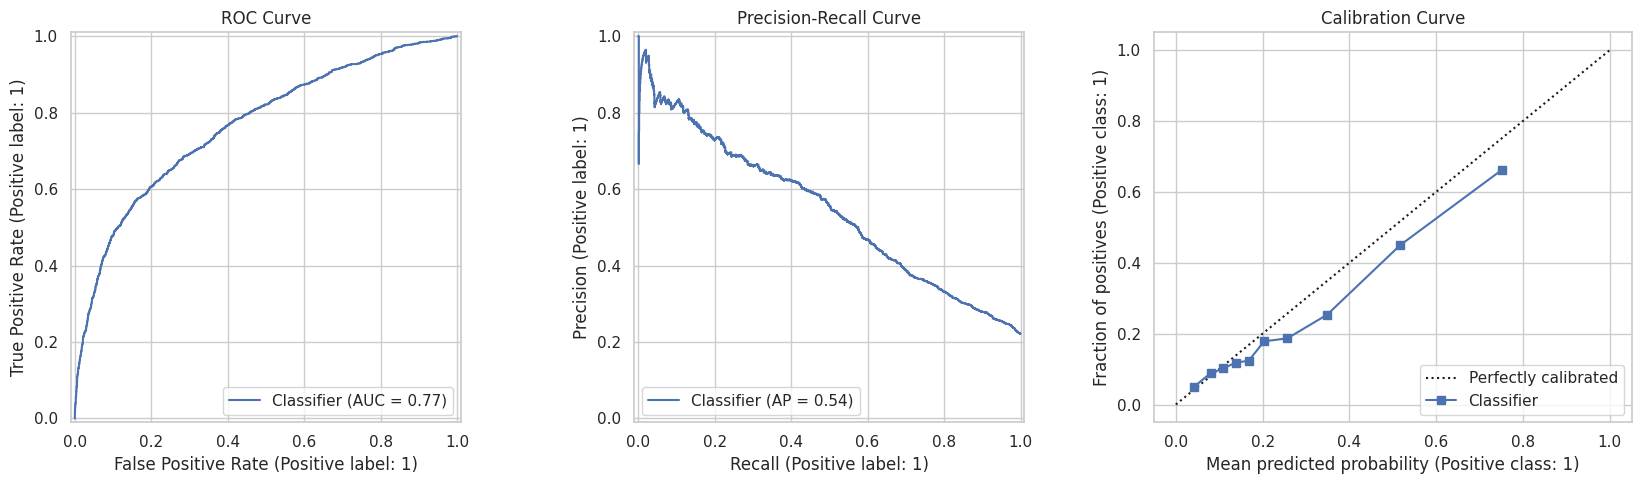

In [68]:
# Display ranking and probability-quality curves

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=axes[0]
)
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=axes[1]
)
axes[1].set_title("Precision-Recall Curve")

CalibrationDisplay.from_predictions(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy="quantile",
    ax=axes[2]
)
axes[2].set_title("Calibration Curve")

plt.tight_layout()
plt.show()


The threshold comparison demonstrates the trade-off between detecting more defaulting customers and incorrectly flagging customers who would not default. ROC-AUC evaluates ranking across thresholds, average precision emphasizes performance on the minority class, and the calibration curve compares predicted probabilities with observed default frequencies.


## 13. Feature Importance and Model Interpretation

Feature importance is extracted from the selected model after preprocessing. For logistic regression, absolute coefficient magnitude is used. For random forest, the model's impurity-based feature importance is used. These measures describe predictive contribution and should not be interpreted as causal effects.


In [69]:
# Extract transformed feature names and model importance

fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_classifier = best_model.named_steps["classifier"]

transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

if hasattr(fitted_classifier, "feature_importances_"):
    feature_importance_values = (
        fitted_classifier.feature_importances_
    )
    importance_method = "Random forest feature importance"

elif hasattr(fitted_classifier, "coef_"):
    feature_importance_values = np.abs(
        fitted_classifier.coef_[0]
    )
    importance_method = "Absolute logistic regression coefficient"

else:
    raise AttributeError(
        "The selected model does not expose feature importance."
    )

feature_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": feature_importance_values
}).sort_values(
    by="importance",
    ascending=False
)

display(feature_importance_df.head(15))


,feature,importance
2,numerical__payment_status_sep,0.06
20,numerical__months_with_delay,0.06
21,numerical__maximum_delay,0.06
0,numerical__limit_balance,0.05
23,numerical__average_payment_amount,0.04
25,numerical__total_payment_amount,0.04
8,numerical__bill_amount_sep,0.04
1,numerical__age,0.04
22,numerical__average_bill_amount,0.04
24,numerical__total_bill_amount,0.04


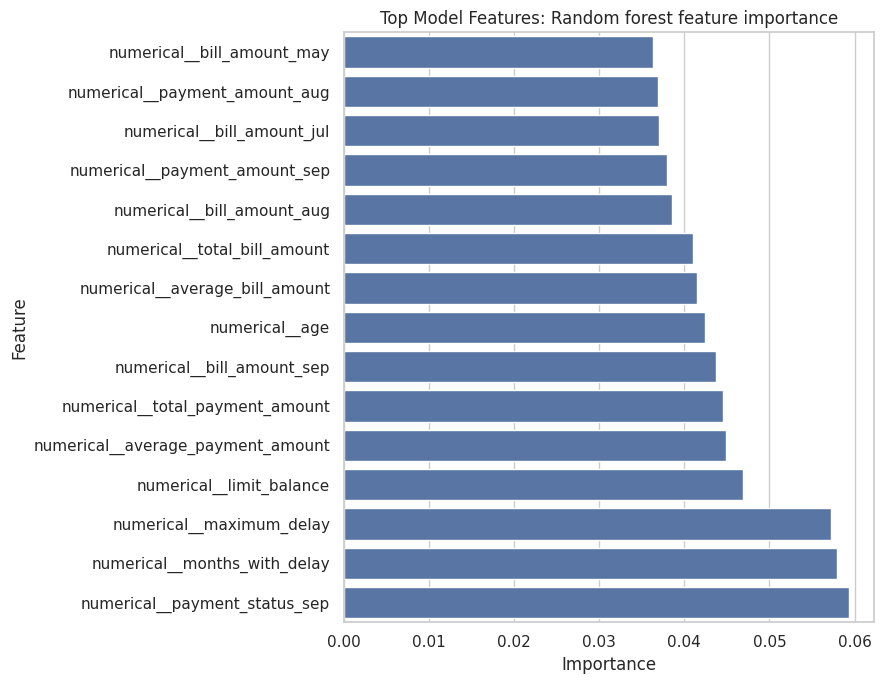

In [70]:
# Plot the most influential model features

top_features = feature_importance_df.head(15).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title(f"Top Model Features: {importance_method}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 14. Conclusions and Limitations

### Conclusions

This project developed an end-to-end machine learning workflow for predicting credit-card default. The analysis combined data-quality assessment, category cleaning, exploratory analysis, behavioral feature engineering, preprocessing pipelines, class-weighted models, and threshold-based evaluation.

Payment-delay behavior showed a strong association with subsequent default. In particular, the persistence and severity of previous delays provided useful summaries of customer payment history. The final comparison between logistic regression and random forest balanced interpretability with nonlinear predictive performance.

The cost-sensitive threshold analysis also demonstrated that the conventional 0.50 threshold is not automatically the most appropriate choice. When false negatives are assumed to be more costly, a different threshold may identify more risky customers at the expense of additional false positives.

### Limitations

- The dataset describes credit-card customers in Taiwan and may not generalize to other countries, institutions, or time periods.
- The financial costs used for threshold selection are illustrative rather than institution-specific monetary estimates.
- Demographic variables may introduce fairness concerns and should not be used automatically in real lending decisions.
- Feature importance describes predictive association, not causality.
- Model performance may change as customer behavior and economic conditions evolve.
- This educational model should not be used as an automated credit-decision system.

### Future Work

- Compare performance with gradient-boosting models.
- Tune model hyperparameters using stratified cross-validation.
- Evaluate fairness metrics across demographic groups.
- Calibrate predicted probabilities when required.
- Use institution-specific financial costs for threshold selection.
- Monitor performance and data drift over time.
